===== MODEL PERFORMANCE =====
Mean Squared Error: 8.227460519607844
R2 Score: 0.8878080447367498


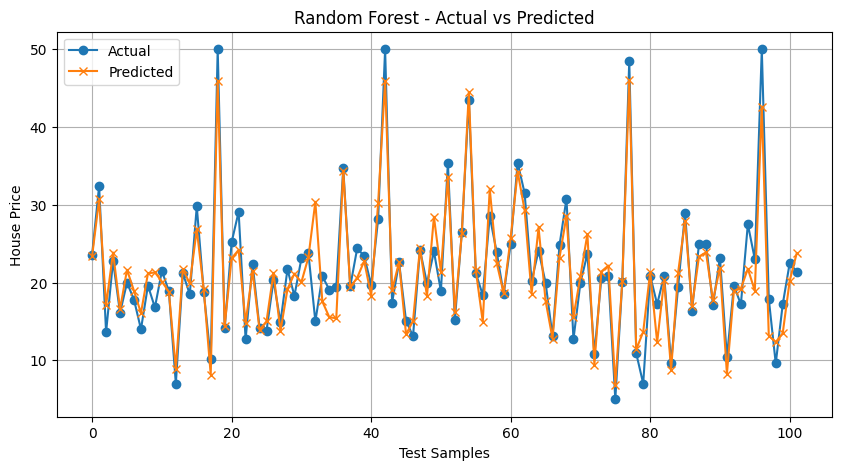

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('HousingData.csv')

target_column = 'MEDV'

X = df.drop(columns=[target_column])
y = df[target_column]

X = X.fillna(X.mean())
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("===== MODEL PERFORMANCE =====")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.title("Random Forest - Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

plt.show()

Dataset Preview:

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Correlation with Selling Price:

Selling_Price             1.000000
Present_Price             0.878983
Fuel_Type_Diesel          0.552339
Kms_Driven                0.029187
Owner                    -0.088344
Years_of_Service         -0.236141
Transmission_Manual      -0.367128
Fuel_Type_Petrol         -0.540571
Seller_Type_Individ

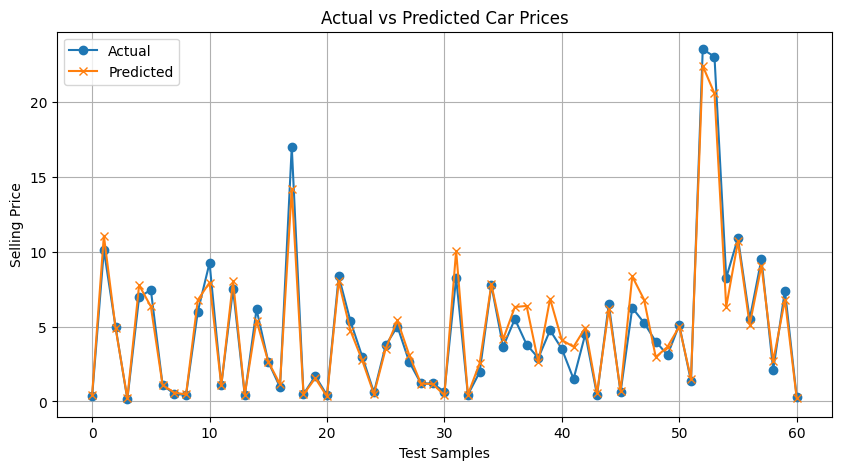

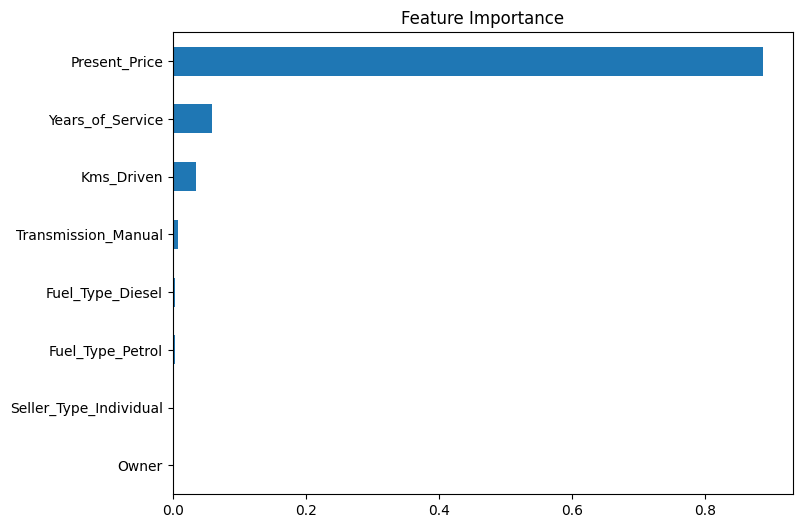


Enter Car Details:
Showroom Price: 5.5
Kilometers Driven: 40000
Number of Previous Owners: 1
Years of Service: 5
Fuel Type (Petrol/Diesel): Petrol
Seller Type (Dealer/Individual): Dealar
Transmission (Manual/Automatic): Manual

💰 Predicted Selling Price: 3.74


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('car.csv')

print("Dataset Preview:\n")
print(df.head())

target_column = 'Selling_Price'

current_year = datetime.datetime.now().year
df['Years_of_Service'] = current_year - df['Year']

df.drop(['Year', 'Car_Name'], axis=1, inplace=True, errors='ignore')

df.fillna(df.mean(numeric_only=True), inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=[target_column])
y = df[target_column]

print("\nCorrelation with Selling Price:\n")
print(df.corr()[target_column].sort_values(ascending=False))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n===== MODEL PERFORMANCE =====")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Test Samples")
plt.ylabel("Selling Price")
plt.legend()
plt.grid(True)
plt.show()

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance")
plt.show()

def predict_price():
    print("\nEnter Car Details:")

    present_price = float(input("Showroom Price: "))
    kms_driven = int(input("Kilometers Driven: "))
    owner = int(input("Number of Previous Owners: "))
    years = int(input("Years of Service: "))

    fuel = input("Fuel Type (Petrol/Diesel): ")
    seller = input("Seller Type (Dealer/Individual): ")
    transmission = input("Transmission (Manual/Automatic): ")

    input_data = {
        'Present_Price': present_price,
        'Kms_Driven': kms_driven,
        'Owner': owner,
        'Years_of_Service': years,
        'Fuel_Type_Diesel': 1 if fuel == 'Diesel' else 0,
        'Seller_Type_Individual': 1 if seller == 'Individual' else 0,
        'Transmission_Manual': 1 if transmission == 'Manual' else 0
    }

    input_df = pd.DataFrame([input_data])

    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    prediction = model.predict(input_df)

    print("\n💰 Predicted Selling Price:", round(prediction[0], 2))


predict_price()